In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import statistics
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

# Import merged dataset

In [ ]:
qfinal_df=pd.read_csv('/content/drive/MyDrive/Capstone-Thesis/Datasets/kiva_small_loans/kivaloan_final_merged_dataset.csv')
print(qfinal_df.shape) #shows num of row and column
qfinal_df.head(3)

(554056, 33)


,Unnamed: 0,funded_amount,loan_amount,activity,sector,use,country,region,partner_id,term_in_months,...,Unemployment (% of labour force),Agricultural production index (2004-2006=100),Food production index (2004-2006=100),Population growth rate (average annual %),Urban population (% of total population),Urban population growth rate (average annual %),Mobile-cellular subscriptions (per 100 inhabitants),Individuals using the Internet (per 100 inhabitants),Loan Theme Type,MPI
0,0,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",Pakistan,Lahore,247.0,12.0,...,5.9,135.0,138.0,2.1,38.8,2.8,66.9,140.0,NaN,0.184
1,1,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,Pakistan,Lahore,247.0,11.0,...,5.9,135.0,138.0,2.1,38.8,2.8,66.9,140.0,Underserved,0.184
2,2,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,India,Maynaguri,334.0,43.0,...,3.4,143.0,142.0,1.2,32.7,2.4,78.8,1052.0,Underserved,0.034


# Post merge Processing and removing the index and type error

In [ ]:
qfinal_df = qfinal_df.drop(columns=[ 'id', 'partner_id'], errors='ignore')
# Find the number of unique rows for each column
unique_counts = qfinal_df.nunique()

# Display the unique counts
print("Number of unique values for each column:\n")
print(unique_counts)

Number of unique values for each column:

Unnamed: 0                                              554056
funded_amount                                              455
loan_amount                                                454
activity                                                   163
sector                                                      15
use                                                     337747
country                                                     73
region                                                    5295
term_in_months                                             144
lender_count                                               441
borrower_genders                                          9064
repayment_interval                                           3
Region                                                      18
GDP: Gross domestic product (million current US$)           73
GDP growth rate (annual %, const. 2005 prices)              50
GDP per capit

In [ ]:
# Standardize the 'borrower_genders' column
def standardize_gender(gender_string):
    if isinstance(gender_string, str):
        genders = gender_string.lower().split(', ')
        if genders[0] == 'female':
            return 'female'
        elif genders[0] == 'male':
            return 'male'
    return gender_string # Return original if not string or doesn't start with male/female

qfinal_df['borrower_genders'] = qfinal_df['borrower_genders'].apply(standardize_gender)

# Print the number of unique values in the 'borrower_genders' column
print("Number of unique values in 'borrower_genders' after standardization:", qfinal_df['borrower_genders'].nunique())
print("\nUnique values for 'borrower_genders':\n", qfinal_df['borrower_genders'].unique())

Number of unique values in 'borrower_genders' after standardization: 2

Unique values for 'borrower_genders':
 ['female' 'male']


In [ ]:
# Count male and female before modification
print("borrower_genders counts before modification:")
print(qfinal_df['borrower_genders'].value_counts())


borrower_genders counts before modification:
borrower_genders
female    429587
male      124469
Name: count, dtype: int64


In [ ]:
# Check the number of females before modification
print("Female count before modification:", qfinal_df[qfinal_df['borrower_genders'] == 'female'].shape[0])

# Replace 'female' with 'male' in 'borrower_genders' column where 'use' contains 'his'
qfinal_df.loc[(qfinal_df['use'].str.contains('his', na=False)) & (qfinal_df['borrower_genders'] == 'female'), 'borrower_genders'] = 'male'

# Check the number of females and males after modification
print("\nGender counts after modification:")
print(qfinal_df['borrower_genders'].value_counts())

Female count before modification: 429587

Gender counts after modification:
borrower_genders
female    424009
male      130047
Name: count, dtype: int64


# Renaming columns

In [ ]:
qfinal_df = qfinal_df.rename(columns={
    'region': 'Sub Region',
    'borrower_genders': 'Gender',
    'GDP: Gross domestic product (million current US$)': 'GDP',
    'GDP growth rate (annual %, const. 2005 prices)': 'GDP_growth'
})

print("Columns after renaming:\n", qfinal_df.columns)

Columns after renaming:
 Index(['Unnamed: 0', 'funded_amount', 'loan_amount', 'activity', 'sector',
       'use', 'country', 'Sub Region', 'term_in_months', 'lender_count',
       'Gender', 'repayment_interval', 'Region', 'GDP', 'GDP_growth',
       'GDP per capita (current US$)', 'Economy: Agriculture (% of GVA)',
       'Economy: Industry (% of GVA)',
       'Economy: Services and other activity (% of GVA)',
       'Employment: Agriculture (% of employed)',
       'Employment: Industry (% of employed)',
       'Employment: Services (% of employed)',
       'Unemployment (% of labour force)',
       'Agricultural production index (2004-2006=100)',
       'Food production index (2004-2006=100)',
       'Population growth rate (average annual %)',
       'Urban population (% of total population)',
       'Urban population growth rate (average annual %)',
       'Mobile-cellular subscriptions (per 100 inhabitants)',
       'Individuals using the Internet (per 100 inhabitants)',
       'L

# Visualization

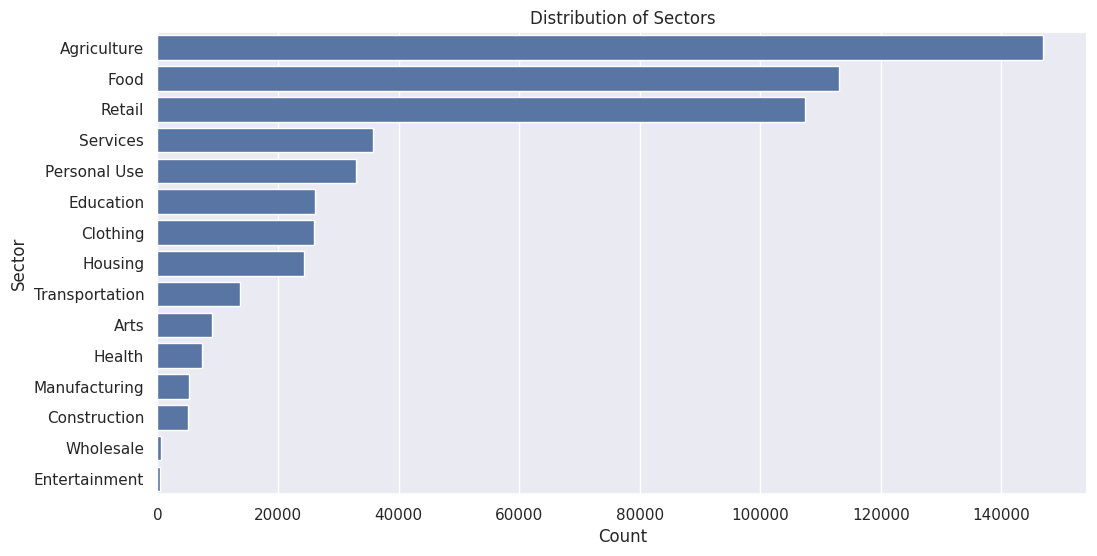

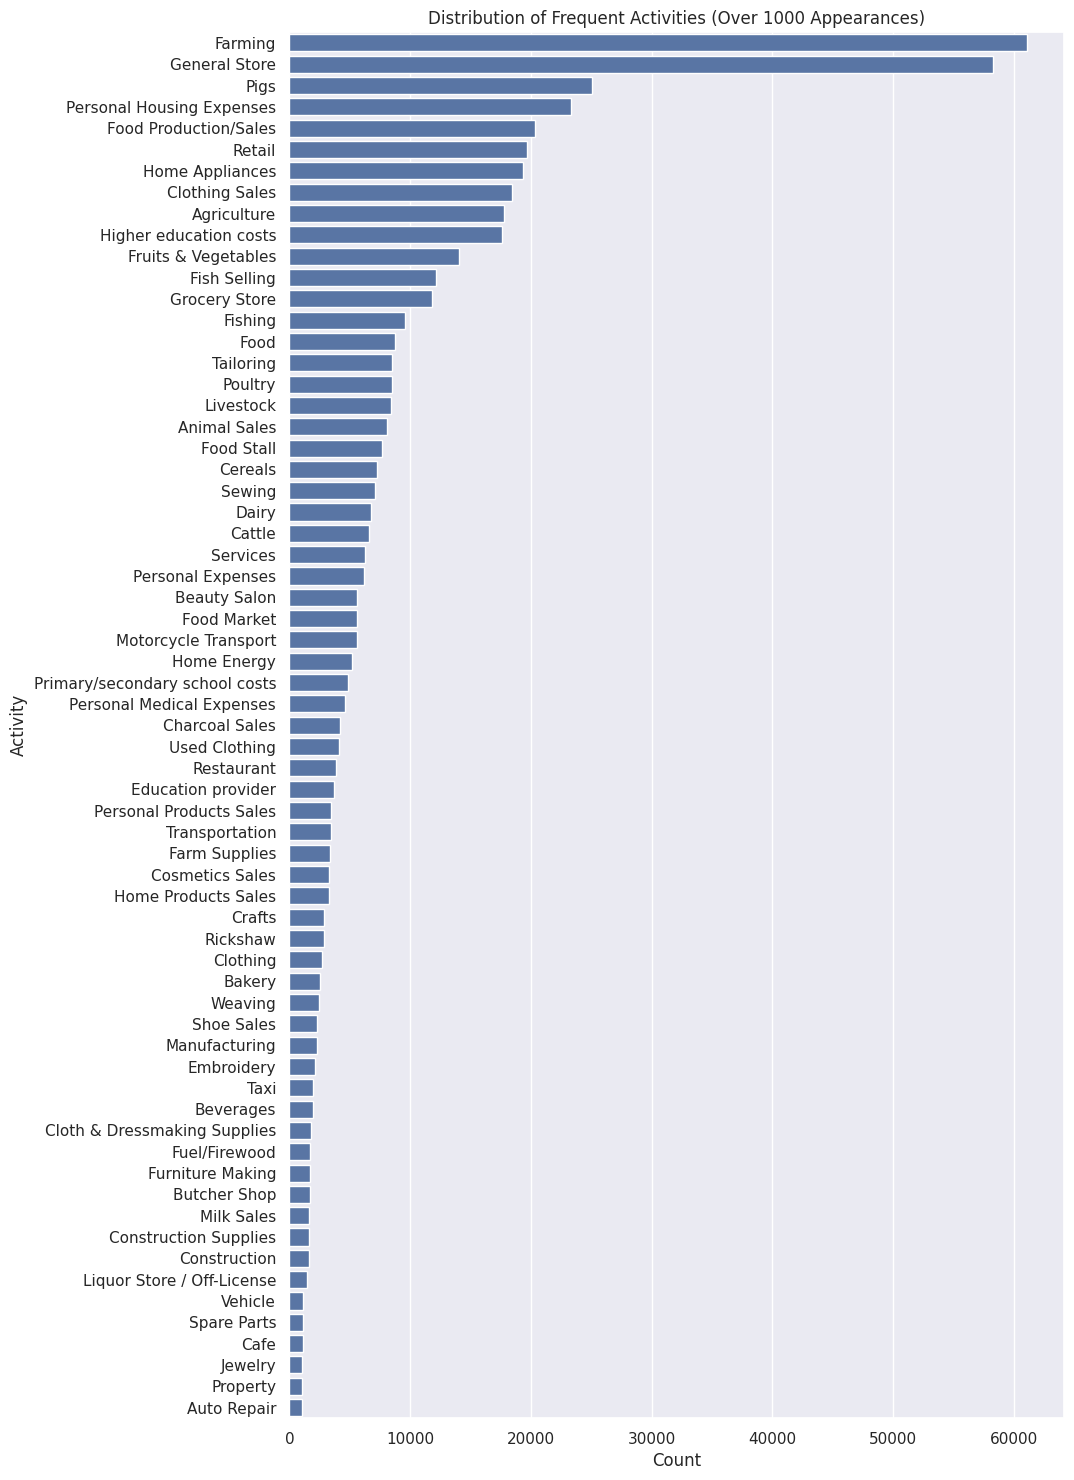

In [ ]:
# Visualize unique sectors
plt.figure(figsize=(12, 6))
sns.countplot(y='sector', data=final_df, order=final_df['sector'].value_counts().index)
plt.title('Distribution of Sectors')
plt.xlabel('Count')
plt.ylabel('Sector')
plt.show()
print()
# Activities with more than 1000 appearances
activity_counts = final_df['activity'].value_counts()
frequent_activities = activity_counts[activity_counts > 1000]

plt.figure(figsize=(10, 18))
sns.countplot(y='activity', data=final_df[final_df['activity'].isin(frequent_activities.index)], order=frequent_activities.index)
plt.title('Distribution of Frequent Activities (Over 1000 Appearances)')
plt.xlabel('Count')
plt.ylabel('Activity')
plt.show()

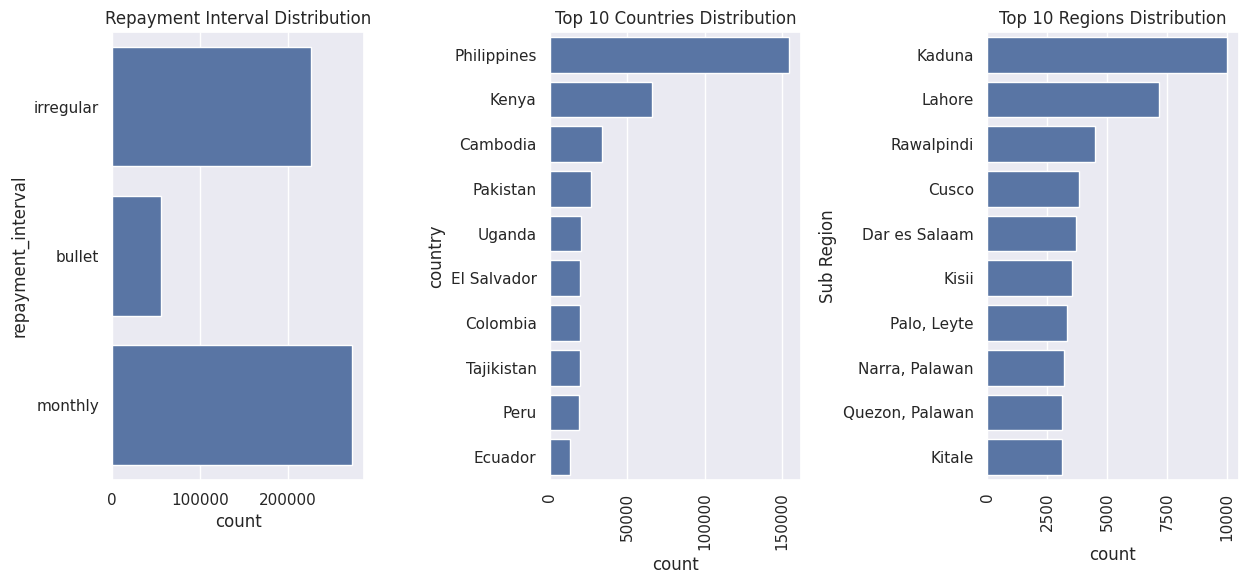

In [ ]:
plt.figure(figsize=(16, 6))


plt.subplot(1, 4, 2)
sns.countplot(y='repayment_interval', data=final_df)
plt.title('Repayment Interval Distribution')

plt.subplot(1, 4, 3)
sns.countplot(y='country', data=final_df, order=final_df['country'].value_counts().index[:10]) # Top 10 countries
plt.title('Top 10 Countries Distribution')
plt.xticks(rotation=90)


plt.subplot(1, 4, 4)
sns.countplot(y='Sub Region', data=final_df, order=final_df['Sub Region'].value_counts().index[:10])  # Top 10 regions
plt.title('Top 10 Regions Distribution')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

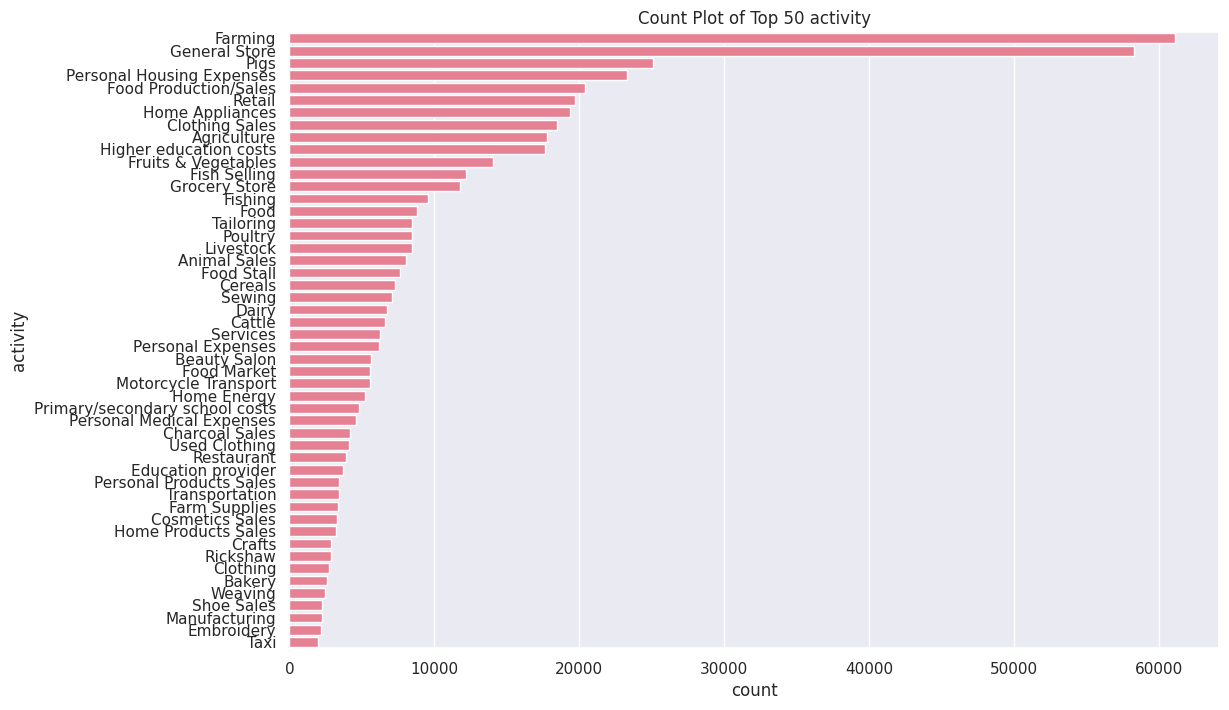

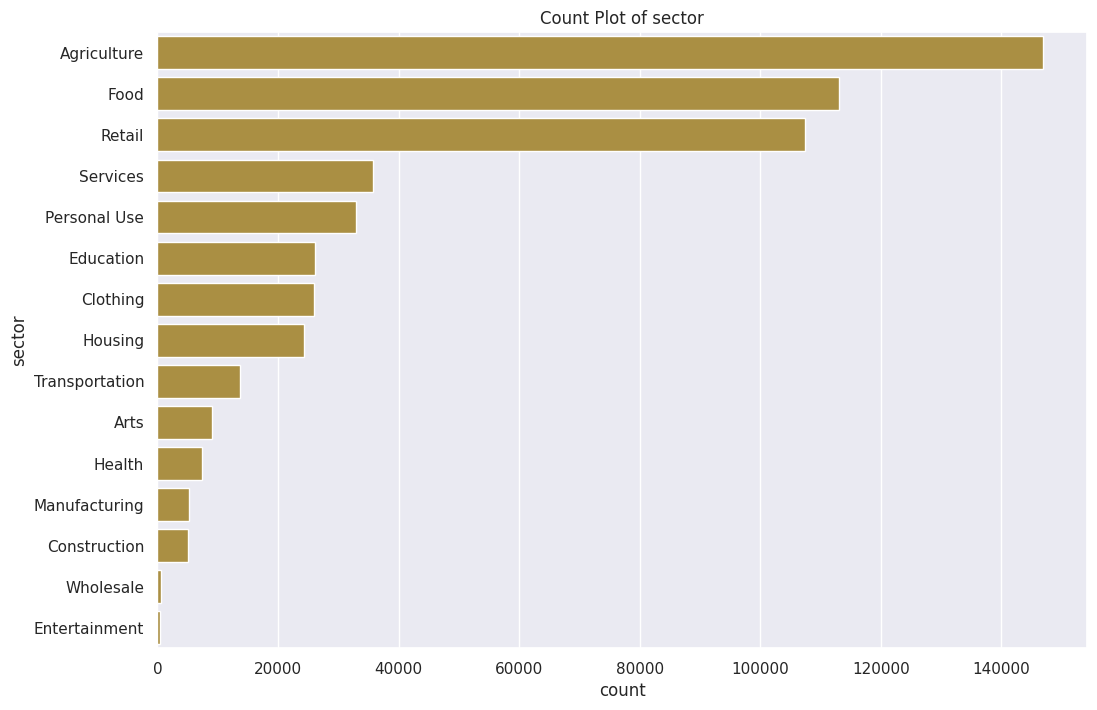

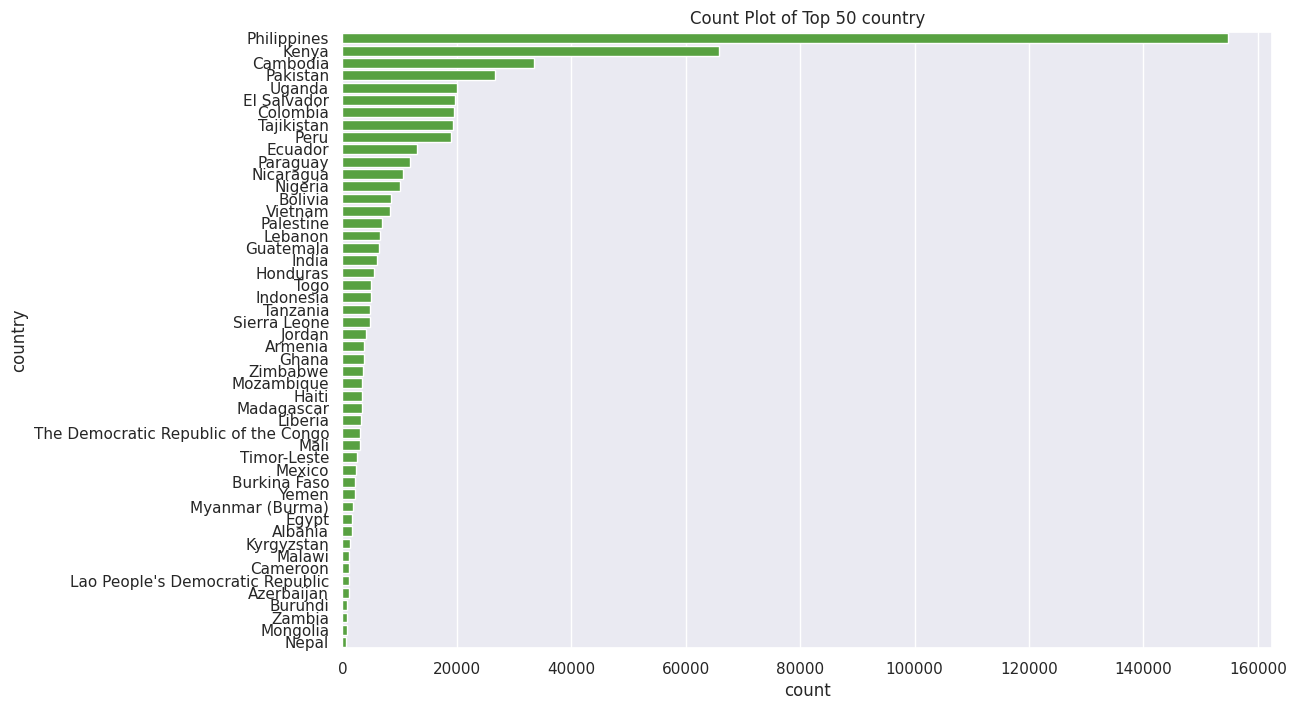

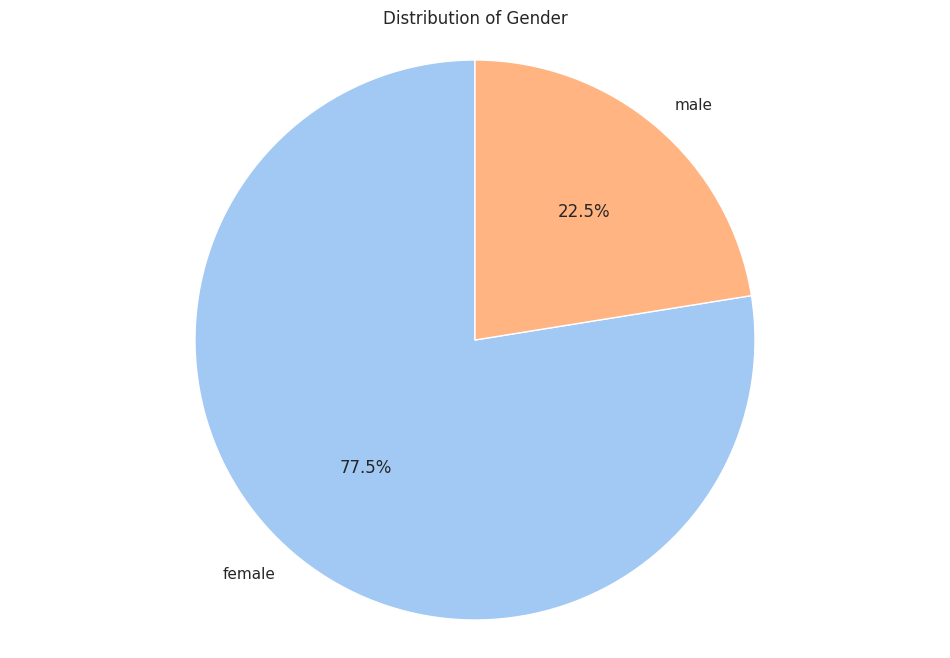

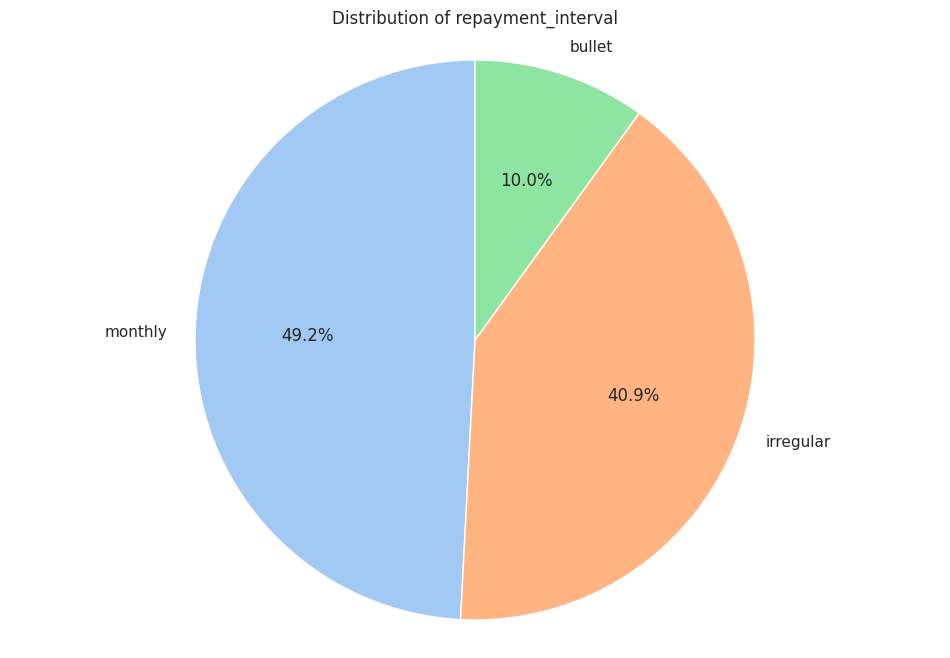

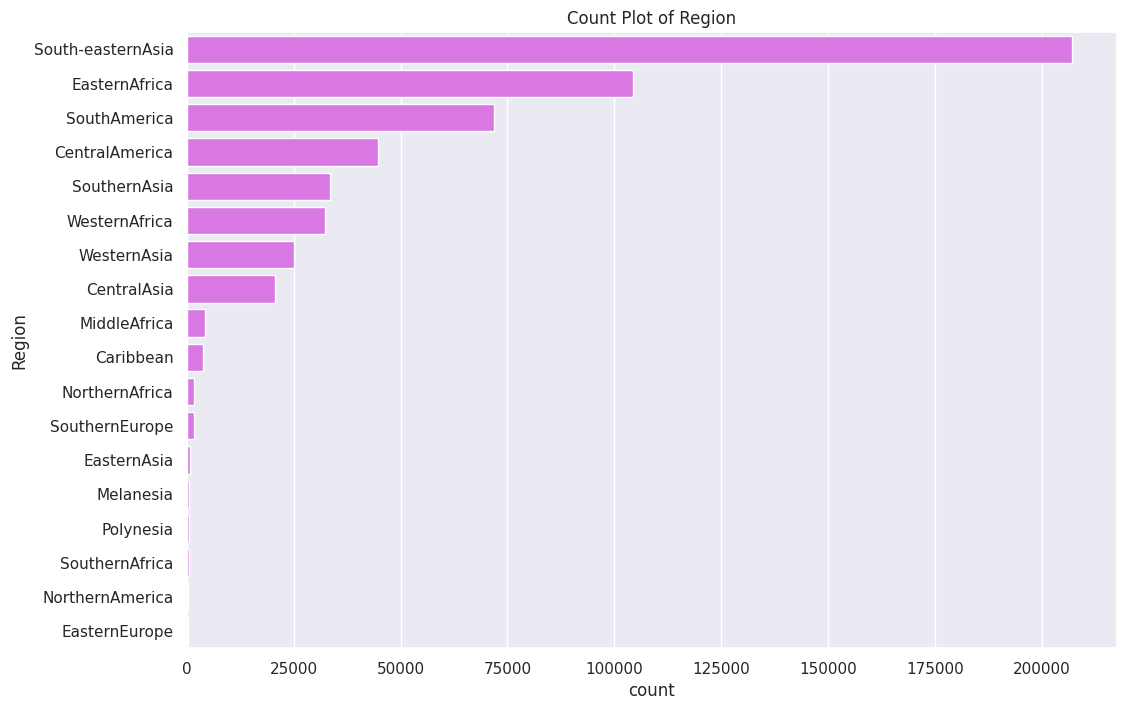

In [ ]:
columns_to_visualize = ['activity', 'sector', 'country', 'Gender', 'repayment_interval', 'Region']
palette = sns.color_palette("husl", len(columns_to_visualize))

for i, column in enumerate(columns_to_visualize):
    plt.figure(figsize=(12, 8))

    # Determine plot type based on data type and unique value count
    if final_df[column].dtype == 'object':
        if final_df[column].nunique() < 10: # Pie chart for categorical with very few unique values
            counts = final_df[column].value_counts()
            plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
            plt.title(f'Distribution of {column}')
            plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

        elif final_df[column].nunique() < 50: # Count plot for categorical with few unique values
            sns.countplot(y=column, data=final_df, order=final_df[column].value_counts().index, color=palette[i])
            plt.title(f'Count Plot of {column}')
        else: # Count plot for top N categorical values with many unique values
            top_n = 50
            top_values = final_df[column].value_counts().nlargest(top_n).index
            sns.countplot(y=column, data=final_df[final_df[column].isin(top_values)], order=top_values, color=palette[i])
            plt.title(f'Count Plot of Top {top_n} {column}')

    elif final_df[column].dtype in ['int64', 'float64']:
        # Histogram for numerical columns
        plt.hist(final_df[column].dropna(), bins='auto')
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')

    plt.show()

# Copy dataset

In [ ]:
final_df = qfinal_df.copy()
print("DataFrame copied to df_copy.")

DataFrame copied to df_copy.


In [ ]:
print("Data types of columns:\n")
print(final_df.dtypes)

numerical_cols = ['funded_amount', 'loan_amount', 'GDP per capita (current US$)', 'MPI']
print("\nDescriptive statistics for numerical columns:\n")
print(final_df[numerical_cols].describe())

Data types of columns:

Unnamed: 0                                                int64
funded_amount                                           float64
loan_amount                                             float64
activity                                                 object
sector                                                   object
use                                                      object
country                                                  object
Sub Region                                               object
term_in_months                                          float64
lender_count                                              int64
Gender                                                   object
repayment_interval                                       object
Region                                                   object
GDP                                                     float64
GDP_growth                                              float64
GDP per capita (

In [ ]:
categorical_cols = ['Sub Region', 'Gender', 'repayment_interval']
print("\nUnique values and counts for categorical columns:\n")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(final_df[col].value_counts())

economic_cols = [
    'GDP', 'GDP_growth', 'Economy: Agriculture (% of GVA)',
    'Economy: Industry (% of GVA)', 'Economy: Services and other activity (% of GVA)',
    'Employment: Agriculture (% of employed)', 'Employment: Industry (% of employed)',
    'Employment: Services (% of employed)', 'Unemployment (% of labour force)',
    'Agricultural production index (2004-2006=100)',
    'Food production index (2004-2006=100)', 'Population growth rate (average annual %)',
    'Urban population (% of total population)', 'Urban population growth rate (average annual %)',
    'Mobile-cellular subscriptions (per 100 inhabitants)',
    'Individuals using the Internet (per 100 inhabitants)', 'Loan Theme Type'
]

print("\nExamining other economic indicator columns:\n")
for col in economic_cols:
    print(f"\n--- {col} ---")
    if final_df[col].dtype == 'object':
        print("Data type: object")
        print("Unique values and counts:")
        print(final_df[col].value_counts())
    else:
        print("Data type: numerical")
        print("Descriptive statistics:")
        print(final_df[col].describe())


Unique values and counts for categorical columns:


--- Sub Region ---
Sub Region
Kaduna                                    10000
Lahore                                     7178
Rawalpindi                                 4496
Cusco                                      3841
Dar es Salaam                              3719
                                          ...  
p-6, lower loboc, oroquieta city              1
p-5 maular, aloran, misamis occidental        1
alejandria                                    1
Mumbwa                                        1
Potia Alfonso Lista, Ifugao                   1
Name: count, Length: 5295, dtype: int64

--- Gender ---
Gender
female    424009
male      130047
Name: count, dtype: int64

--- repayment_interval ---
repayment_interval
monthly      272483
irregular    226354
bullet        55219
Name: count, dtype: int64

Examining other economic indicator columns:


--- GDP ---
Data type: numerical
Descriptive statistics:
count    5.540560e+05
mean   

# Feature engineering for risk score


In [ ]:
# Impute missing values for numerical columns with the median
numerical_cols_to_impute = [
    'funded_amount', 'loan_amount', 'GDP per capita (current US$)', 'MPI',
    'GDP', 'GDP_growth', 'Economy: Agriculture (% of GVA)',
    'Economy: Industry (% of GVA)', 'Economy: Services and other activity (% of GVA)',
    'Employment: Agriculture (% of employed)', 'Employment: Industry (% of employed)',
    'Employment: Services (% of employed)', 'Unemployment (% of labour force)',
    'Agricultural production index (2004-2006=100)',
    'Food production index (2004-2006=100)', 'Population growth rate (average annual %)',
    'Urban population (% of total population)', 'Urban population growth rate (average annual %)',
    'Mobile-cellular subscriptions (per 100 inhabitants)',
    'Individuals using the Internet (per 100 inhabitants)'
]

# Convert 'Unemployment (% of labour force)' to numeric, coercing errors
final_df['Unemployment (% of labour force)'] = pd.to_numeric(final_df['Unemployment (% of labour force)'], errors='coerce')

for col in numerical_cols_to_impute:
    if final_df[col].isnull().any():
        median_val = final_df[col].median()
        final_df[col].fillna(median_val, inplace=True)

# Check for remaining missing values in these columns
print("Missing values after imputation:\n")
print(final_df[numerical_cols_to_impute].isnull().sum())

Missing values after imputation:

funded_amount                                           0
loan_amount                                             0
GDP per capita (current US$)                            0
MPI                                                     0
GDP                                                     0
GDP_growth                                              0
Economy: Agriculture (% of GVA)                         0
Economy: Industry (% of GVA)                            0
Economy: Services and other activity (% of GVA)         0
Employment: Agriculture (% of employed)                 0
Employment: Industry (% of employed)                    0
Employment: Services (% of employed)                    0
Unemployment (% of labour force)                        0
Agricultural production index (2004-2006=100)           0
Food production index (2004-2006=100)                   0
Population growth rate (average annual %)               0
Urban population (% of total populatio

In [ ]:
# Create interaction terms and ratios
final_df['loan_to_gdp_per_capita_ratio'] = final_df['loan_amount'] / final_df['GDP per capita (current US$)']
final_df['loan_to_mpi_ratio'] = final_df['loan_amount'] / (final_df['MPI'] + 1e-6) # Add small value to avoid division by zero

# Address potential outliers in numerical features by capping
numerical_cols_for_outliers = [
    'funded_amount', 'loan_amount', 'term_in_months', 'lender_count',
    'GDP per capita (current US$)', 'MPI', 'GDP', 'GDP_growth',
    'Economy: Agriculture (% of GVA)', 'Economy: Industry (% of GVA)',
    'Economy: Services and other activity (% of GVA)',
    'Employment: Agriculture (% of employed)', 'Employment: Industry (% of employed)',
    'Employment: Services (% of employed)', 'Unemployment (% of labour force)',
    'Agricultural production index (2004-2006=100)',
    'Food production index (2004-2006=100)', 'Population growth rate (average annual %)',
    'Urban population (% of total population)', 'Urban population growth rate (average annual %)',
    'Mobile-cellular subscriptions (per 100 inhabitants)',
    'Individuals using the Internet (per 100 inhabitants)',

    'loan_to_gdp_per_capita_ratio', 'loan_to_mpi_ratio'
]

for col in numerical_cols_for_outliers:
    if col in final_df.columns:
        upper_limit = final_df[col].quantile(0.99)
        final_df[col] = np.where(final_df[col] > upper_limit, upper_limit, final_df[col])
        lower_limit = final_df[col].quantile(0.01)
        final_df[col] = np.where(final_df[col] < lower_limit, lower_limit, final_df[col])


print("New columns created and outliers capped.")
display(final_df[['loan_to_gdp_per_capita_ratio', 'loan_to_mpi_ratio']].head())

New columns created and outliers capped.


,loan_to_gdp_per_capita_ratio,loan_to_mpi_ratio
0,0.212706,1630.425922
1,0.407686,3124.983016
2,0.092925,4411.634952
3,0.141804,1086.950614
4,0.283607,2173.901229


In [ ]:
# Apply one-hot encoding to categorical features
categorical_cols_to_encode = ['Gender', 'repayment_interval']
final_df = pd.get_dummies(final_df, columns=categorical_cols_to_encode, drop_first=True)

# Note: 'Sub Region' and 'Region' have too many unique values for simple one-hot encoding.
# We might consider other encoding techniques or use them directly if the model can handle high cardinality.
# For now, we will not encode 'Sub Region' and 'Region' with one-hot encoding.
print("Categorical features encoded.")
print(final_df.columns)

# Standardize numerical features
from sklearn.preprocessing import StandardScaler

numerical_cols_to_standardize = [
    'funded_amount', 'loan_amount', 'term_in_months', 'lender_count',
    'GDP per capita (current US$)', 'MPI', 'GDP', 'GDP_growth',
    'Economy: Agriculture (% of GVA)', 'Economy: Industry (% of GVA)',
    'Economy: Services and other activity (% of GVA)',
    'Employment: Agriculture (% of employed)', 'Employment: Industry (% of employed)',
    'Employment: Services (% of employed)', 'Unemployment (% of labour force)',
    'Agricultural production index (2004-2006=100)',
    'Food production index (2004-2006=100)', 'Population growth rate (average annual %)',
    'Urban population (% of total population)', 'Urban population growth rate (average annual %)',
    'Mobile-cellular subscriptions (per 100 inhabitants)',
    'Individuals using the Internet (per 100 inhabitants)',

    'loan_to_gdp_per_capita_ratio', 'loan_to_mpi_ratio'
]

scaler = StandardScaler()
final_df[numerical_cols_to_standardize] = scaler.fit_transform(final_df[numerical_cols_to_standardize])

print("Numerical features standardized.")
display(final_df[numerical_cols_to_standardize].head())

Categorical features encoded.
Index(['Unnamed: 0', 'funded_amount', 'loan_amount', 'activity', 'sector',
       'use', 'country', 'Sub Region', 'term_in_months', 'lender_count',
       'Region', 'GDP', 'GDP_growth', 'GDP per capita (current US$)',
       'Economy: Agriculture (% of GVA)', 'Economy: Industry (% of GVA)',
       'Economy: Services and other activity (% of GVA)',
       'Employment: Agriculture (% of employed)',
       'Employment: Industry (% of employed)',
       'Employment: Services (% of employed)',
       'Unemployment (% of labour force)',
       'Agricultural production index (2004-2006=100)',
       'Food production index (2004-2006=100)',
       'Population growth rate (average annual %)',
       'Urban population (% of total population)',
       'Urban population growth rate (average annual %)',
       'Mobile-cellular subscriptions (per 100 inhabitants)',
       'Individuals using the Internet (per 100 inhabitants)',
       'Loan Theme Type', 'MPI', 'loan_to_g

,funded_amount,loan_amount,term_in_months,lender_count,GDP per capita (current US$),MPI,GDP,GDP_growth,Economy: Agriculture (% of GVA),Economy: Industry (% of GVA),...,Unemployment (% of labour force),Agricultural production index (2004-2006=100),Food production index (2004-2006=100),Population growth rate (average annual %),Urban population (% of total population),Urban population growth rate (average annual %),Mobile-cellular subscriptions (per 100 inhabitants),Individuals using the Internet (per 100 inhabitants),loan_to_gdp_per_capita_ratio,loan_to_mpi_ratio
0,-0.482540,-0.512920,-0.155308,-0.310957,-0.712951,0.472009,0.318586,0.287778,0.705053,-1.417927,...,-0.193488,0.261292,0.331948,0.191524,-0.314890,0.169193,-1.422912,-0.881183,-0.334094,-0.369459
1,-0.146983,-0.186543,-0.304722,-0.206776,-0.712951,0.472009,0.318586,0.287778,0.705053,-1.417927,...,-0.193488,0.261292,0.331948,0.191524,-0.314890,0.169193,-1.422912,-0.881183,0.007815,-0.344593
2,-0.665571,-0.690943,4.476531,-0.623501,-0.596187,-0.767092,7.243437,0.924905,-0.124483,0.348773,...,-0.808644,0.664122,0.516136,-0.861411,-0.658078,-0.143510,-0.942041,1.255075,-0.544136,-0.323185
3,-0.604561,-0.631602,-0.304722,-0.519320,-0.712951,0.472009,0.318586,0.287778,0.705053,-1.417927,...,-0.193488,0.261292,0.331948,0.191524,-0.314890,0.169193,-1.422912,-0.881183,-0.458424,-0.378502
4,-0.360519,-0.394237,0.143521,-0.102595,-0.712951,0.472009,0.318586,0.287778,0.705053,-1.417927,...,-0.193488,0.261292,0.331948,0.191524,-0.314890,0.169193,-1.422912,-0.881183,-0.209764,-0.360417


#Adjusting weights

In [ ]:
# 1. Select the engineered numerical features, the one-hot encoded categorical features (Gender and repayment_interval),
# and potentially the 'Region' column.
# Based on the analysis and common lending practices, we'll select features that are likely indicators of risk.
# Higher loan amounts, longer terms, lower economic indicators (GDP, MPI, employment), higher unemployment,
# and certain repayment intervals or genders (if applicable in the context) might indicate higher risk.

selected_features_for_risk = [
    'funded_amount', 'loan_amount', 'term_in_months', 'lender_count',
    'GDP per capita (current US$)', 'MPI', 'GDP_growth',
    'Unemployment (% of labour force)',
    'loan_to_gdp_per_capita_ratio', 'loan_to_mpi_ratio',
    'Gender_male', 'repayment_interval_irregular', 'repayment_interval_monthly'
]

# We need to handle the 'Region' column. Since one-hot encoding is not suitable due to high cardinality,
# and we haven't determined another encoding strategy, we will exclude 'Region' for now from the weighted sum.
# This is a simplification and a more sophisticated approach might involve regional risk profiling.

# Ensure all selected features exist in the DataFrame
selected_features_for_risk = [feature for feature in selected_features_for_risk if feature in final_df.columns]

# 2. Assign weights to the selected features based on their expected impact on loan risk.
# These are initial, simplified weights. A more rigorous approach would involve statistical analysis
# or domain expert input.
# Features expected to increase risk get positive weights. Features expected to decrease risk get negative weights.
# The magnitude of the weight reflects the perceived importance.

# Reverse the sign for features where higher values indicate lower risk (after standardization,
# higher values are generally better, so we need to make them contribute negatively to risk score).
# For example, higher GDP per capita, higher GDP growth, higher employment, more lenders, lower loan_to_gdp/mpi ratio
# might indicate lower risk.
# Features that directly indicate higher risk might include loan_amount, term_in_months, unemployment, male gender (if statistically relevant), irregular repayment.

weights = {
    'funded_amount': -0.4,
    'loan_amount': 1.0,
    'term_in_months': 0.5,
    'lender_count': -0.6,
    'GDP per capita (current US$)': -1.0,
    'MPI': 1.0,
    'GDP_growth': -0.5,
    'Unemployment (% of labour force)': 1.5,
    'loan_to_gdp_per_capita_ratio': 1.5,
    'loan_to_mpi_ratio': 1.5,
    'Gender_male': 0.8,
    'repayment_interval_irregular': 0.5,
    'repayment_interval_monthly': -0.4
}

# Ensure weights dictionary only contains selected features
weights = {feature: weight for feature, weight in weights.items() if feature in selected_features_for_risk}

# 3. Calculate the 'risk_score'
# Since features are standardized, we can directly apply weights.
# Ensure features with negative weights are correctly interpreted (e.g., multiplying by a negative weight
# for a standardized feature will make it contribute negatively to the risk score if the original value was high,
# which is correct for features like GDP per capita where high values mean low risk).

final_df['risk_score'] = final_df[selected_features_for_risk].apply(
    lambda row: sum(row[feature] * weights[feature] for feature in selected_features_for_risk), axis=1
)


# 4. Normalize the final 'risk_score' to a specific range (e.g., 0 to 100)
min_risk = final_df['risk_score'].min()
max_risk = final_df['risk_score'].max()

# Avoid division by zero if min and max are the same
if max_risk - min_risk == 0:
    final_df['risk_score_normalized'] = 50 # Assign a neutral score if all scores are the same
else:
    final_df['risk_score_normalized'] = ((final_df['risk_score'] - min_risk) / (max_risk - min_risk)) * 100

print("Risk score calculated and normalized.")
print(final_df[['risk_score', 'risk_score_normalized']].describe())

Risk score calculated and normalized.
          risk_score  risk_score_normalized
count  554056.000000          554056.000000
mean        0.195326              22.176217
std         3.326775               9.945995
min        -7.222261               0.000000
25%        -2.236168              14.906827
50%        -0.861412              19.016909
75%         1.798181              26.968243
max        26.226126             100.000000


# Eligibility Prediction

## Threshold for small loan (100 - 2000) USD, which is 70-75%

In [ ]:
# Define the threshold for eligibility based on the normalized risk score.
# Based on the descriptive statistics (mean around 21, 75th percentile 25.07),
# setting the threshold at the 75th percentile means that the top 25% of loans
# by risk score will be considered ineligible.
eligibility_threshold = final_df['risk_score_normalized'].quantile(0.75)
print(f"Eligibility threshold set at the 75th percentile of normalized risk score: {eligibility_threshold}")

# Create the 'eligibility' column
# 'yes' if risk_score_normalized is below the threshold, 'no' otherwise.
final_df['eligibility'] = np.where(final_df['risk_score_normalized'] < eligibility_threshold, 'yes', 'no')

# Print the value counts for the 'eligibility' column
print("\nValue counts for the 'eligibility' column:")
print(final_df['eligibility'].value_counts())

Eligibility threshold set at the 75th percentile of normalized risk score: 26.807432025349318

Value counts for the 'eligibility' column:
eligibility
yes    415542
no     138514
Name: count, dtype: int64


## Threshold for Traditional Personal/SME Loans (1000 - 50,000) USD, which is 10-30%

In [ ]:
eligibility_threshold = final_df['risk_score_normalized'].quantile(0.30)
print(f"Eligibility threshold set at the 30th percentile of normalized risk score: {eligibility_threshold}")

# Create the 'eligibility' column
# 'yes' if risk_score_normalized is below the threshold, 'no' otherwise.
final_df['eligibility'] = np.where(final_df['risk_score_normalized'] < eligibility_threshold, 'yes', 'no')

# Print the value counts for the 'eligibility' column
print("\nValue counts for the 'eligibility' column:")
print(final_df['eligibility'].value_counts())

Eligibility threshold set at the 30th percentile of normalized risk score: 15.316162768410798

Value counts for the 'eligibility' column:
eligibility
no     387872
yes    166184
Name: count, dtype: int64


In [ ]:
final_df.head(6)

,Unnamed: 0,funded_amount,loan_amount,activity,sector,use,country,Sub Region,term_in_months,lender_count,...,Loan Theme Type,MPI,loan_to_gdp_per_capita_ratio,loan_to_mpi_ratio,Gender_male,repayment_interval_irregular,repayment_interval_monthly,risk_score,risk_score_normalized,eligibility
0,0,-0.482540,-0.512920,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",Pakistan,Lahore,-0.155308,-0.310957,...,NaN,0.472009,-0.334094,-0.369459,False,True,False,-0.015474,21.545992,no
1,1,-0.146983,-0.186543,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,Pakistan,Lahore,-0.304722,-0.206776,...,Underserved,0.472009,0.007815,-0.344593,False,True,False,0.589627,23.355051,no
2,2,-0.665571,-0.690943,Transportation,Transportation,To repair their old cycle-van and buy another ...,India,Maynaguri,4.476531,-0.623501,...,Underserved,-0.767092,-0.544136,-0.323185,False,False,False,-0.959653,18.723199,no
3,3,-0.604561,-0.631602,Embroidery,Arts,to purchase an embroidery machine and a variet...,Pakistan,Lahore,-0.304722,-0.519320,...,Underserved,0.472009,-0.458424,-0.378502,False,True,False,-0.235097,20.889390,no
4,4,-0.360519,-0.394237,Milk Sales,Food,to purchase one buffalo.,Pakistan,Abdul Hakeem,0.143521,-0.102595,...,General,0.472009,-0.209764,-0.360417,False,False,True,-0.621144,19.735232,no
5,6,-0.604561,-0.631602,Dairy,Agriculture,To purchase a dairy cow and start a milk produ...,India,Maynaguri,4.476531,-0.519320,...,Underserved,-0.767092,-0.489819,-0.298718,False,False,False,-0.869049,18.994075,no


#Final merge

In [ ]:
# Select the columns to merge from final_df
columns_to_merge = ['Unnamed: 0', 'risk_score', 'risk_score_normalized', 'eligibility']
final_df_subset = final_df[columns_to_merge]

# Merge the selected columns into qfinal_df using 'Unnamed: 0'
qfinal_df = pd.merge(qfinal_df, final_df_subset, on='Unnamed: 0', how='left')

print("Merged 'risk_score', 'risk_score_normalized', and 'eligibility' columns into qfinal_df.")
qfinal_df.head(6)

Merged 'risk_score', 'risk_score_normalized', and 'eligibility' columns into qfinal_df.


,Unnamed: 0,funded_amount,loan_amount,activity,sector,use,country,Sub Region,term_in_months,lender_count,...,Population growth rate (average annual %),Urban population (% of total population),Urban population growth rate (average annual %),Mobile-cellular subscriptions (per 100 inhabitants),Individuals using the Internet (per 100 inhabitants),Loan Theme Type,MPI,risk_score,risk_score_normalized,eligibility
0,0,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",Pakistan,Lahore,12.0,12,...,2.1,38.8,2.8,66.9,140.0,NaN,0.184,-0.015474,21.545992,no
1,1,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,Pakistan,Lahore,11.0,14,...,2.1,38.8,2.8,66.9,140.0,Underserved,0.184,0.589627,23.355051,no
2,2,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,India,Maynaguri,43.0,6,...,1.2,32.7,2.4,78.8,1052.0,Underserved,0.034,-0.959653,18.723199,no
3,3,200.0,200.0,Embroidery,Arts,to purchase an embroidery machine and a variet...,Pakistan,Lahore,11.0,8,...,2.1,38.8,2.8,66.9,140.0,Underserved,0.184,-0.235097,20.889390,no
4,4,400.0,400.0,Milk Sales,Food,to purchase one buffalo.,Pakistan,Abdul Hakeem,14.0,16,...,2.1,38.8,2.8,66.9,140.0,General,0.184,-0.621144,19.735232,no
5,6,200.0,200.0,Dairy,Agriculture,To purchase a dairy cow and start a milk produ...,India,Maynaguri,43.0,8,...,1.2,32.7,2.4,78.8,1052.0,Underserved,0.034,-0.869049,18.994075,no


In [ ]:
print(qfinal_df.columns)

Index(['Unnamed: 0', 'funded_amount', 'loan_amount', 'activity', 'sector',
       'use', 'country', 'Sub Region', 'term_in_months', 'lender_count',
       'Gender', 'repayment_interval', 'Region', 'GDP', 'GDP_growth',
       'GDP per capita (current US$)', 'Economy: Agriculture (% of GVA)',
       'Economy: Industry (% of GVA)',
       'Economy: Services and other activity (% of GVA)',
       'Employment: Agriculture (% of employed)',
       'Employment: Industry (% of employed)',
       'Employment: Services (% of employed)',
       'Unemployment (% of labour force)',
       'Agricultural production index (2004-2006=100)',
       'Food production index (2004-2006=100)',
       'Population growth rate (average annual %)',
       'Urban population (% of total population)',
       'Urban population growth rate (average annual %)',
       'Mobile-cellular subscriptions (per 100 inhabitants)',
       'Individuals using the Internet (per 100 inhabitants)',
       'Loan Theme Type', 'MPI', '

#Post merge optimization

In [ ]:
columns_to_drop = ['Unnamed: 0', 'funded_amount',
       'Mobile-cellular subscriptions (per 100 inhabitants)',
       'Individuals using the Internet (per 100 inhabitants)',
       'Loan Theme Type']

qfinal_df = qfinal_df.drop(columns=columns_to_drop, errors='ignore')

print("Columns dropped successfully.")
print(qfinal_df.columns)

Columns dropped successfully.
Index(['loan_amount', 'activity', 'sector', 'use', 'country', 'Sub Region',
       'term_in_months', 'lender_count', 'Gender', 'repayment_interval',
       'Region', 'GDP', 'GDP_growth', 'GDP per capita (current US$)',
       'Economy: Agriculture (% of GVA)', 'Economy: Industry (% of GVA)',
       'Economy: Services and other activity (% of GVA)',
       'Employment: Agriculture (% of employed)',
       'Employment: Industry (% of employed)',
       'Employment: Services (% of employed)',
       'Unemployment (% of labour force)',
       'Agricultural production index (2004-2006=100)',
       'Food production index (2004-2006=100)',
       'Population growth rate (average annual %)',
       'Urban population (% of total population)',
       'Urban population growth rate (average annual %)', 'MPI', 'risk_score',
       'risk_score_normalized', 'eligibility'],
      dtype='object')


#download

In [ ]:
'''
from google.colab import files

# Define the file name
output_file_name = 'micro_to_personal_loan_kiva_data_analysis.csv'

# Save the DataFrame to a CSV file
qfinal_df.to_csv(output_file_name, index=False)

# Download the file
files.download(output_file_name)

print(f"Initiating download of '{output_file_name}'")
'''

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Initiating download of 'micro_to_personal_loan_kiva_data_analysis.csv'


In [ ]:
print("Number of rows and columns in qfinal_df:", qfinal_df.shape)

Number of rows and columns in qfinal_df: (554056, 30)


#dummy try

In [ ]:
'''# Filter only existing selected features
selected_features_for_risk = [feature for feature in selected_features_for_risk if feature in final_df.columns]

# Updated weights based on economic understanding of microloans in underdeveloped regions
weights = {
    'funded_amount': -0.4,
    'loan_amount': 1.0,
    'term_in_months': 0.5,
    'lender_count': -0.6,
    'GDP per capita (current US$)': -1.0,
    'MPI': 1.0,
    'GDP_growth': -0.5,
    'Unemployment (% of labour force)': 1.5,
    'loan_to_gdp_per_capita_ratio': 1.5,
    'loan_to_mpi_ratio': 1.5,
    'Gender_male': 0.8,
    'repayment_interval_irregular': 0.3,
    'repayment_interval_monthly': -0.4
}
# Filter weights to only use available features
weights = {feature: weight for feature, weight in weights.items() if feature in selected_features_for_risk}

# Compute risk score
final_df['risk_score'] = final_df[selected_features_for_risk].apply(
    lambda row: sum(row[feature] * weights[feature] for feature in selected_features_for_risk), axis=1
)

# Normalize to 0–100
min_risk = final_df['risk_score'].min()
max_risk = final_df['risk_score'].max()
final_df['risk_score_normalized'] = (
    50 if max_risk - min_risk == 0
    else ((final_df['risk_score'] - min_risk) / (max_risk - min_risk)) * 100
)

print("✅ Risk score calculated and normalized.")
print(final_df[['risk_score', 'risk_score_normalized']].describe())
'''

'# Filter only existing selected features\nselected_features_for_risk = [feature for feature in selected_features_for_risk if feature in final_df.columns]\n\n# Updated weights based on economic understanding of microloans in underdeveloped regions\nweights = {\n    \'funded_amount\': -0.4,\n    \'loan_amount\': 1.0,\n    \'term_in_months\': 0.5,\n    \'lender_count\': -0.6,\n    \'GDP per capita (current US$)\': -1.0,\n    \'MPI\': 1.0,\n    \'GDP_growth\': -0.5,\n    \'Unemployment (% of labour force)\': 1.5,\n    \'loan_to_gdp_per_capita_ratio\': 1.5,\n    \'loan_to_mpi_ratio\': 1.5,\n    \'Gender_male\': 0.8,\n    \'repayment_interval_irregular\': 0.3,\n    \'repayment_interval_monthly\': -0.4\n}\n# Filter weights to only use available features\nweights = {feature: weight for feature, weight in weights.items() if feature in selected_features_for_risk}\n\n# Compute risk score\nfinal_df[\'risk_score\'] = final_df[selected_features_for_risk].apply(\n    lambda row: sum(row[feature] * w

In [ ]:
#dummy
'''from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Feature selection – still domain-driven but with fewer redundancies
selected_features = [
    'funded_amount', 'term_in_months', 'lender_count',
    'GDP per capita (current US$)', 'MPI', 'GDP_growth',
    'Unemployment (% of labour force)',
    'loan_to_gdp_per_capita_ratio', 'loan_to_mpi_ratio',
    'Gender_male', 'repayment_interval_irregular', 'repayment_interval_monthly'
]

# 2. Drop highly correlated redundant features
# Optionally drop 'loan_amount' if highly correlated with 'funded_amount'
if 'loan_amount' in final_df.columns and 'funded_amount' in final_df.columns:
    correlation = final_df[['loan_amount', 'funded_amount']].corr().iloc[0,1]
    if abs(correlation) > 0.95:
        print(f"Dropping 'loan_amount' due to high correlation ({correlation:.2f}) with 'funded_amount'")
        final_df.drop(columns=['loan_amount'], inplace=True)
    else:
        selected_features.append('loan_amount')

# 3. Keep only existing columns
selected_features = [f for f in selected_features if f in final_df.columns]

# 4. Standardize features
scaler = StandardScaler()
X = final_df[selected_features]
X_scaled = scaler.fit_transform(X)

# 5. Create a dummy target for unsupervised risk scoring (e.g., use 'loan_amount' or simulate)
# We'll train on loan amount as proxy risk (assumption: high loans = higher risk), or create synthetic target if needed
y = final_df['loan_amount'] if 'loan_amount' in final_df else np.random.rand(len(final_df))

# 6. Train a Random Forest to determine feature importance (better than manual weights)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)
importances = rf.feature_importances_

# Normalize the importances to sum to 1, then scale to 10 for stronger influence
weights = {feature: importance * 10 for feature, importance in zip(selected_features, importances)}

# 7. Compute risk score (dot product of scaled features and weights)
final_df['risk_score'] = X_scaled @ np.array([weights[f] for f in selected_features])

# 8. Normalize risk score to 0–100 range
min_risk = final_df['risk_score'].min()
max_risk = final_df['risk_score'].max()

final_df['risk_score_normalized'] = (
    50 if max_risk == min_risk
    else ((final_df['risk_score'] - min_risk) / (max_risk - min_risk)) * 100
)

# 9. Output
print("✅ Optimized risk score calculated and normalized.")
print("📊 Feature Importances Used as Weights:")
print(dict(sorted(weights.items(), key=lambda x: -x[1])))
print(final_df[['risk_score', 'risk_score_normalized']].describe())
'''

'from sklearn.ensemble import RandomForestRegressor\nfrom sklearn.preprocessing import StandardScaler\nimport numpy as np\n\n# 1. Feature selection – still domain-driven but with fewer redundancies\nselected_features = [\n    \'funded_amount\', \'term_in_months\', \'lender_count\',\n    \'GDP per capita (current US$)\', \'MPI\', \'GDP_growth\',\n    \'Unemployment (% of labour force)\',\n    \'loan_to_gdp_per_capita_ratio\', \'loan_to_mpi_ratio\',\n    \'Gender_male\', \'repayment_interval_irregular\', \'repayment_interval_monthly\'\n]\n\n# 2. Drop highly correlated redundant features\n# Optionally drop \'loan_amount\' if highly correlated with \'funded_amount\'\nif \'loan_amount\' in final_df.columns and \'funded_amount\' in final_df.columns:\n    correlation = final_df[[\'loan_amount\', \'funded_amount\']].corr().iloc[0,1]\n    if abs(correlation) > 0.95:\n        print(f"Dropping \'loan_amount\' due to high correlation ({correlation:.2f}) with \'funded_amount\'")\n        final_df.d

#Correlations

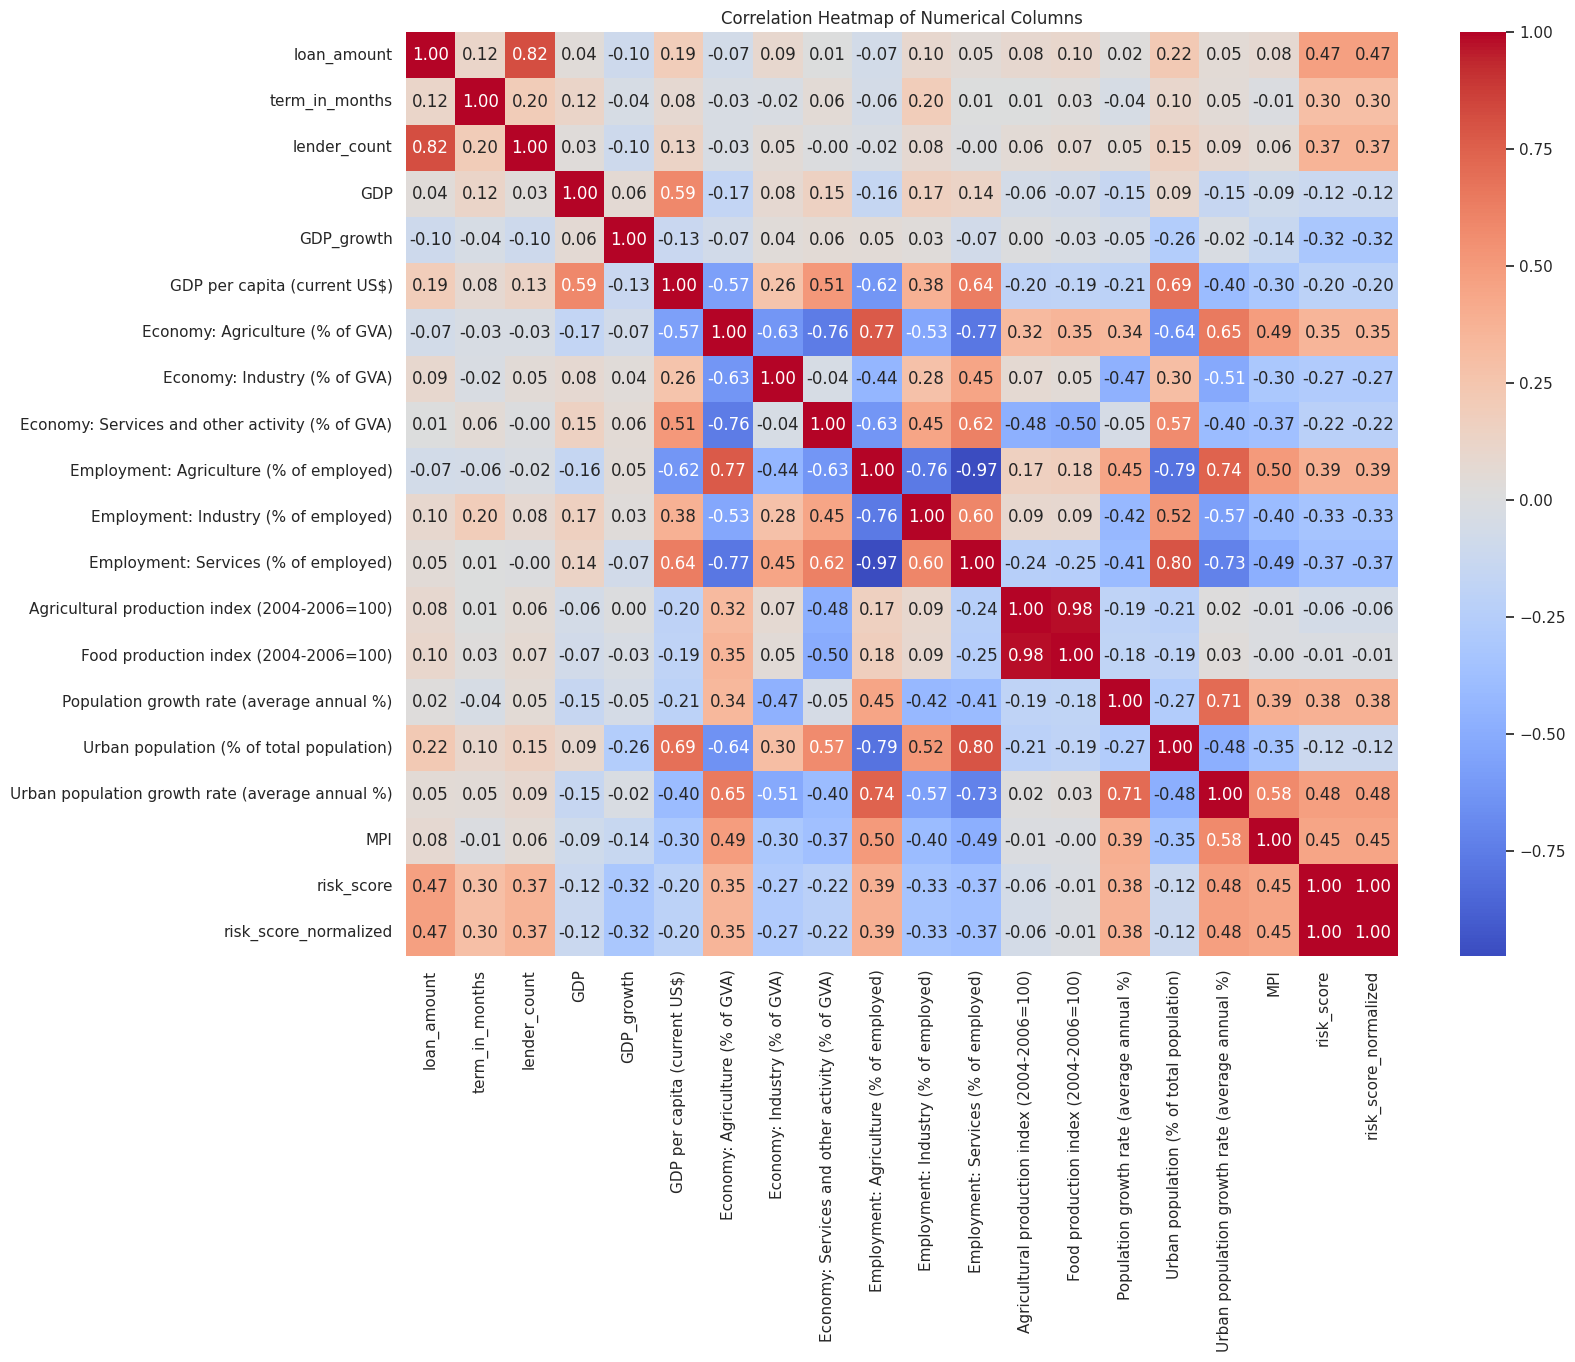

In [ ]:
# Calculate the correlation matrix
correlation_matrix = qfinal_df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

In [ ]:
# Identify highly correlated columns (absolute correlation value above a certain threshold, e.g., 0.7)
high_corr_threshold = 0.7
highly_correlated_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > high_corr_threshold:
            colname_i = correlation_matrix.columns[i]
            colname_j = correlation_matrix.columns[j]
            highly_correlated_pairs.append((colname_i, colname_j, correlation_matrix.iloc[i, j]))

print("Highly correlated numerical column pairs (absolute correlation > 0.7):")
for col1, col2, corr_value in highly_correlated_pairs:
    print(f"- {col1} and {col2}: {corr_value:.2f}")

# Get the unique columns involved in highly correlated pairs
highly_correlated_cols = list(set([col for pair in highly_correlated_pairs for col in pair[:2]]))

print("\nColumns involved in highly correlated pairs:")
print(highly_correlated_cols)

Highly correlated numerical column pairs (absolute correlation > 0.7):
- lender_count and loan_amount: 0.82
- Economy: Services and other activity (% of GVA) and Economy: Agriculture (% of GVA): -0.76
- Employment: Agriculture (% of employed) and Economy: Agriculture (% of GVA): 0.77
- Employment: Industry (% of employed) and Employment: Agriculture (% of employed): -0.76
- Employment: Services (% of employed) and Economy: Agriculture (% of GVA): -0.77
- Employment: Services (% of employed) and Employment: Agriculture (% of employed): -0.97
- Food production index (2004-2006=100) and Agricultural production index (2004-2006=100): 0.98
- Urban population (% of total population) and Employment: Agriculture (% of employed): -0.79
- Urban population (% of total population) and Employment: Services (% of employed): 0.80
- Urban population growth rate (average annual %) and Employment: Agriculture (% of employed): 0.74
- Urban population growth rate (average annual %) and Employment: Service

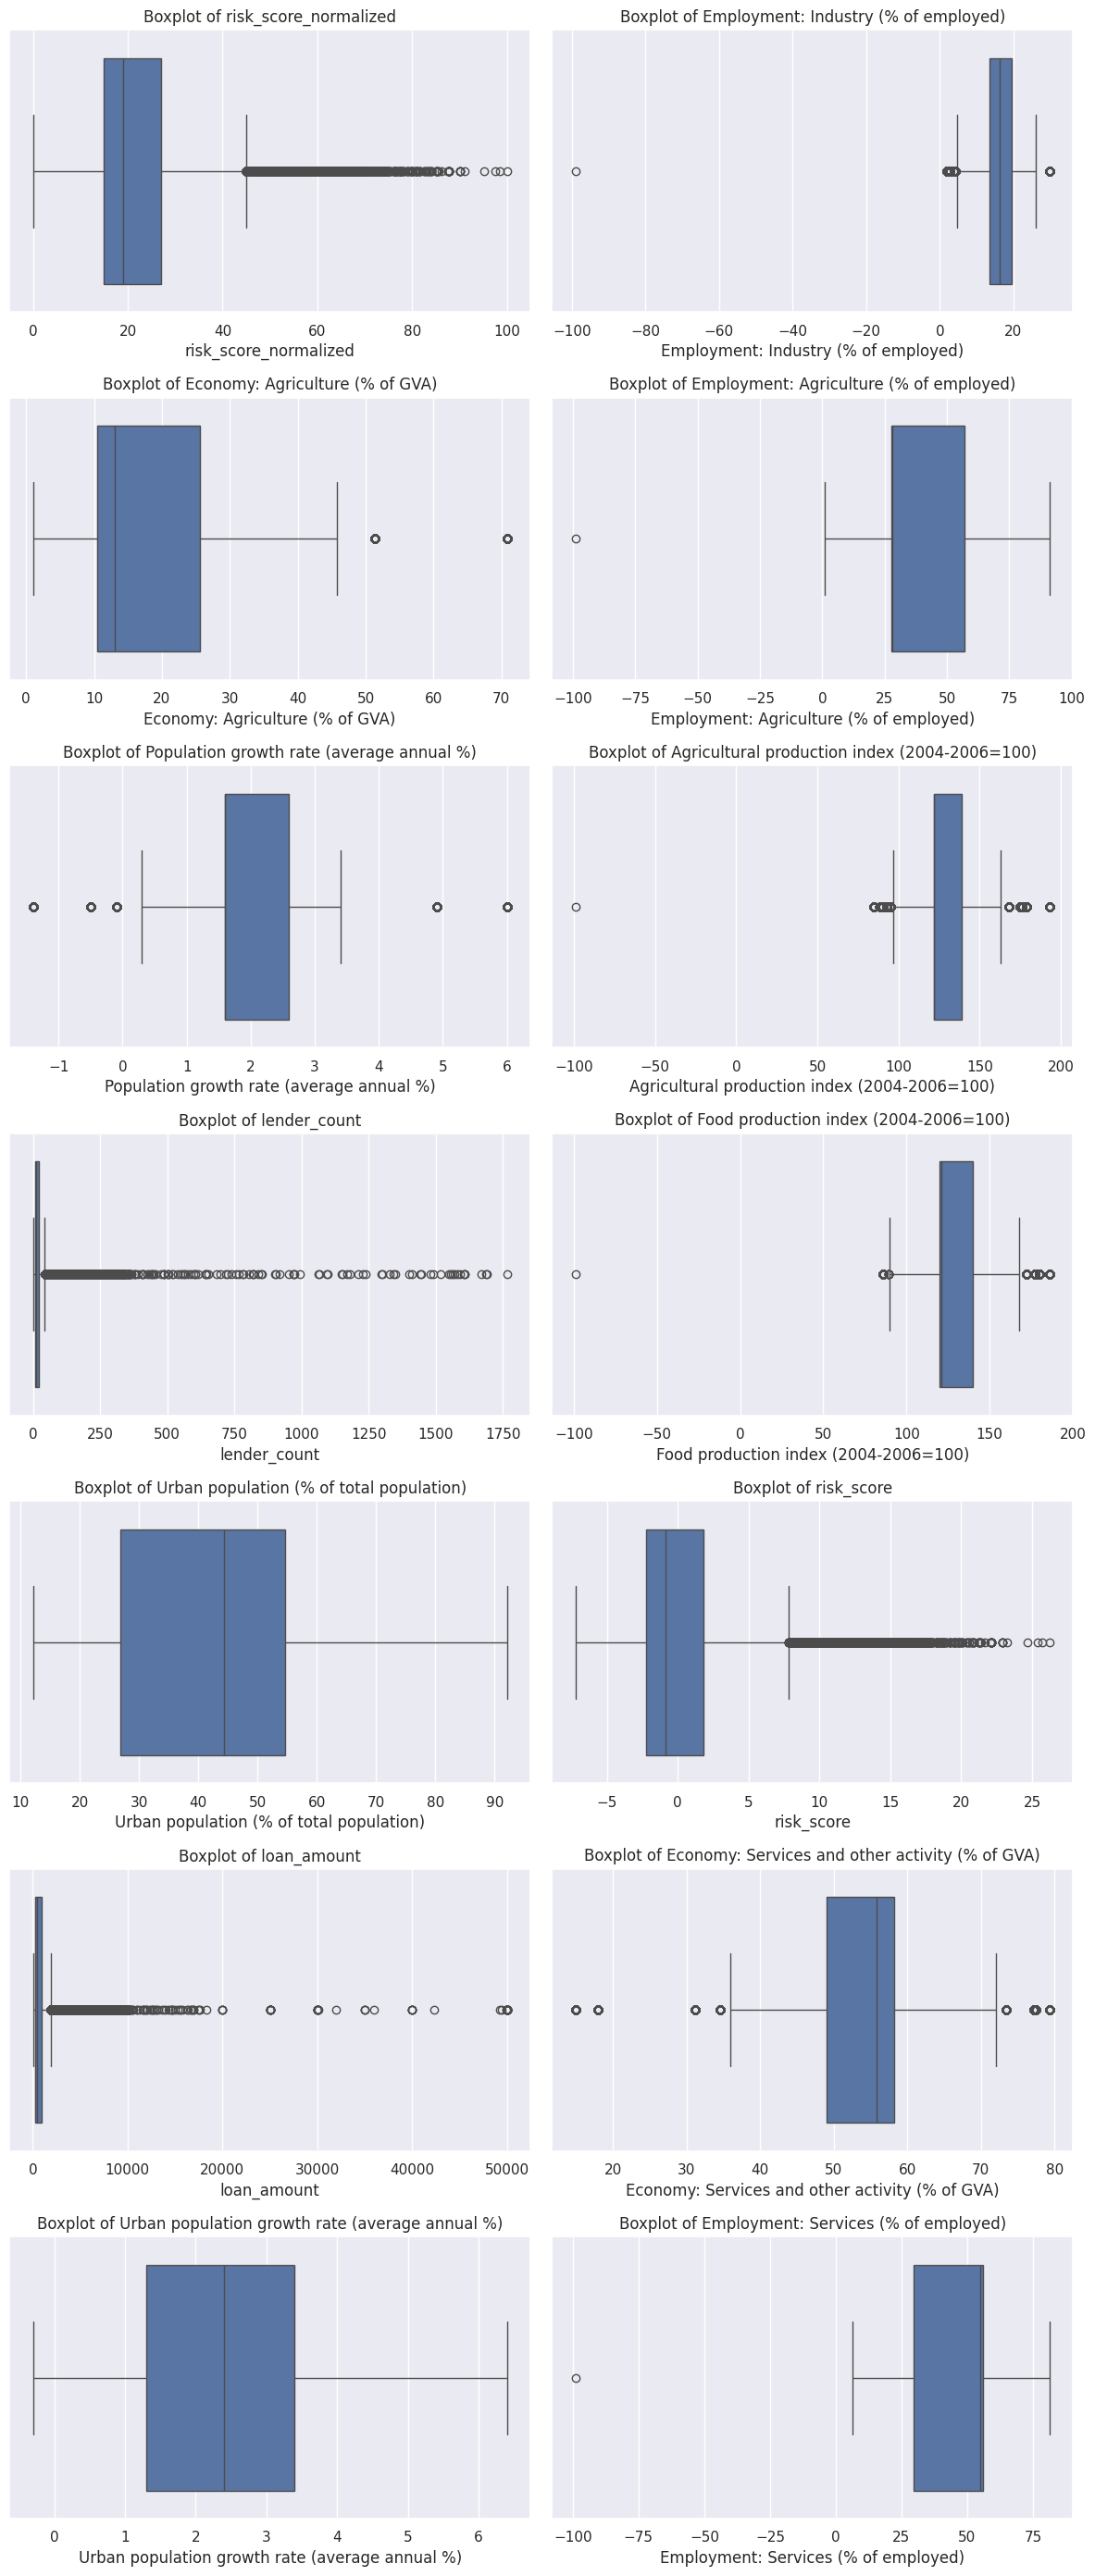

In [ ]:
import math

# Calculate the number of rows needed for subplots (2 plots per row)
n_cols = 2
n_rows = math.ceil(len(highly_correlated_cols) / n_cols)

# Generate boxplots for highly correlated columns, two per line
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4)) # Adjusted figure size and subplots

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, col in enumerate(highly_correlated_cols):

    sns.boxplot(x=qfinal_df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()